### Importa los datos
Dataset con diferentes fármacos, sus efectos y ratings de los clientes.

Importa el dataset *drugLibTrain_raw.tsv*

In [1]:
import pandas as pd

df = pd.read_csv('data/drugLibTrain_raw.tsv', sep='\t', index_col=0)
df.head()

,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


### Descriptive Analysis

Quedate únicamente con las columnas que podamos manejar: Columnas numéricas y columnas categóricas con pocas categorías (menos de 10)

In [2]:
# Hacer una lista de columnas que cumples esas condiciones
selected_columns = []

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        selected_columns.append(col)
    elif df[col].nunique() < 10:
        selected_columns.append(col)

df_filtered = df[selected_columns].copy()
print("Columnas seleccionadas:", df_filtered.columns.tolist())

Columnas seleccionadas: ['rating', 'effectiveness', 'sideEffects']


#### Transforma las columnas categóricas

Transforma las columnas categoricas a numericas mediante dummies

In [3]:
df_dummies = pd.get_dummies(df_filtered)
df_dummies.head()

# aqui tiene sentido hacer un label encioding porque los dummies tienen una jerarquia intrinseca

,rating,effectiveness_Considerably Effective,effectiveness_Highly Effective,effectiveness_Ineffective,effectiveness_Marginally Effective,effectiveness_Moderately Effective,sideEffects_Extremely Severe Side Effects,sideEffects_Mild Side Effects,sideEffects_Moderate Side Effects,sideEffects_No Side Effects,sideEffects_Severe Side Effects
2202,4,False,True,False,False,False,False,True,False,False,False
3117,1,False,True,False,False,False,False,False,False,False,True
1146,10,False,True,False,False,False,False,False,False,True,False
3947,3,False,False,False,True,False,False,True,False,False,False
1951,2,False,False,False,True,False,False,False,False,False,True


#### Evalua cual es la mejor K

Utiliza silhouette_score para evaluar cual es la mejor K.

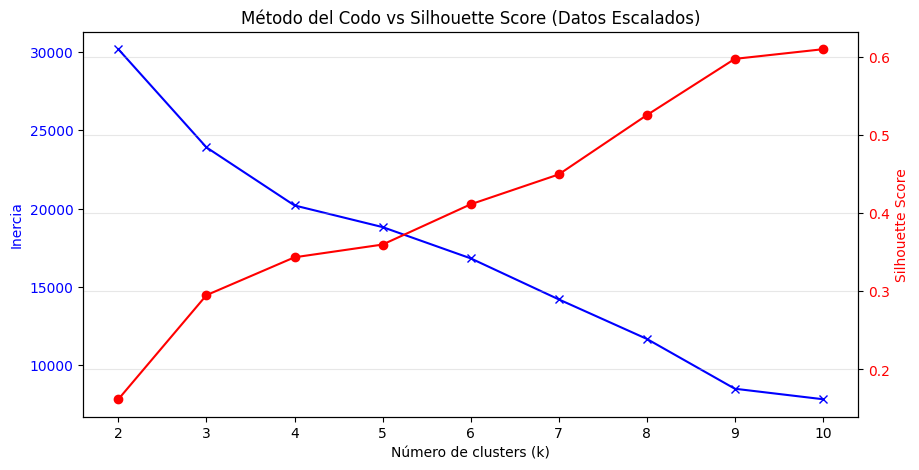

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler # <--- Nueva importación
import matplotlib.pyplot as plt

# 1. Escalar los datos
# Es fundamental hacer esto ANTES de entrar al bucle de K-Means
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_dummies)

inercias = []
sil_scores = []
k_values = range(2, 11)

for k in k_values:
    # Usamos df_scaled en lugar de df_dummies
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(df_scaled)
    
    inercias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(df_scaled, labels))

# 2. Visualización comparativa
fig, ax1 = plt.subplots(figsize=(10, 5))

# Eje para la Inercia (Codo)
ax1.plot(k_values, inercias, 'bx-', label='Inercia (Codo)')
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Eje para Silhouette
ax2 = ax1.twinx()
ax2.plot(k_values, sil_scores, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Método del Codo vs Silhouette Score (Datos Escalados)')
plt.grid(True, alpha=0.3)
plt.show()

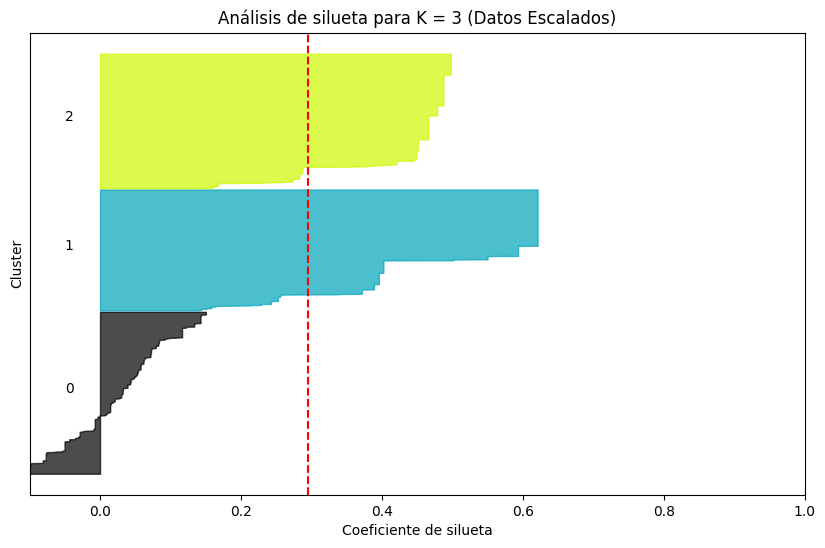

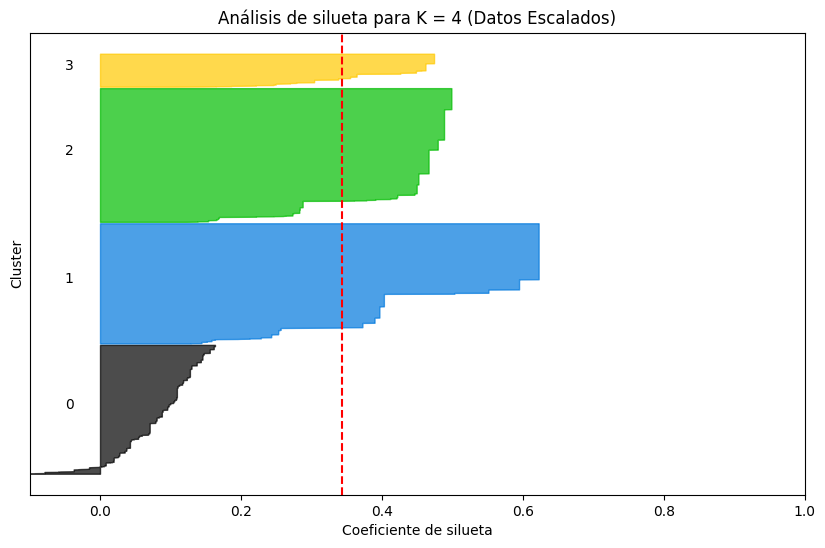

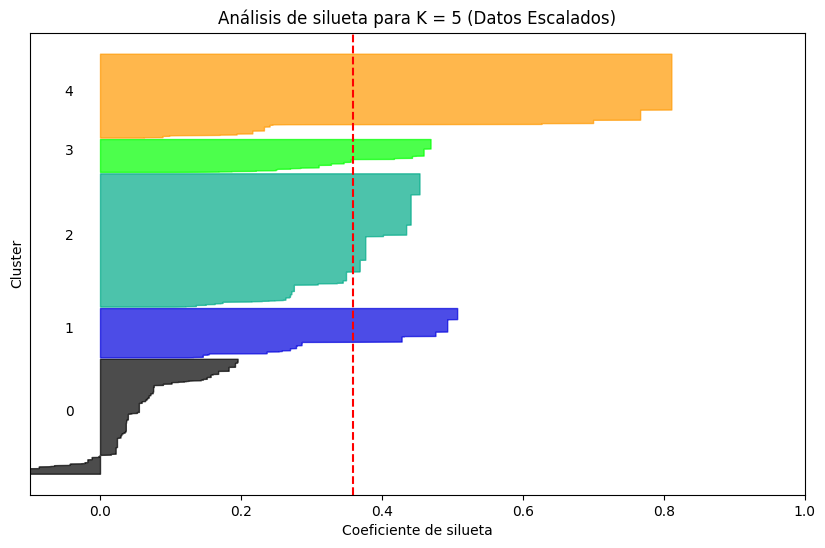

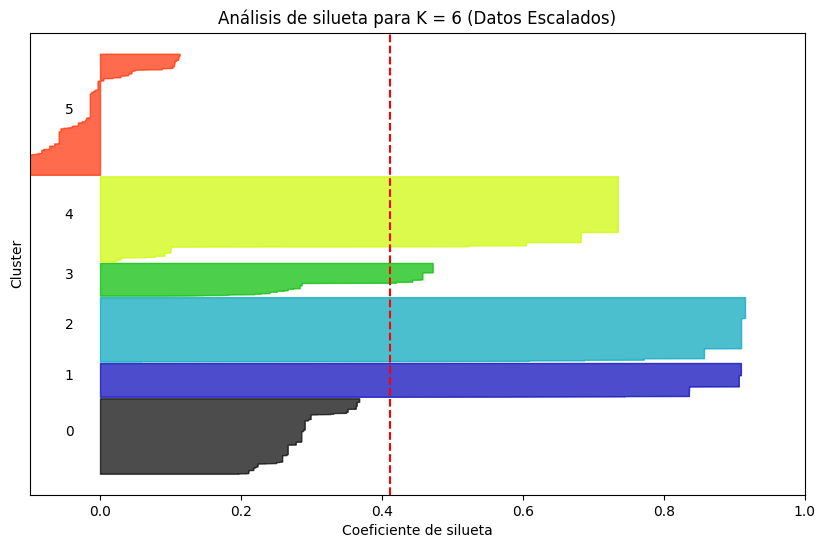

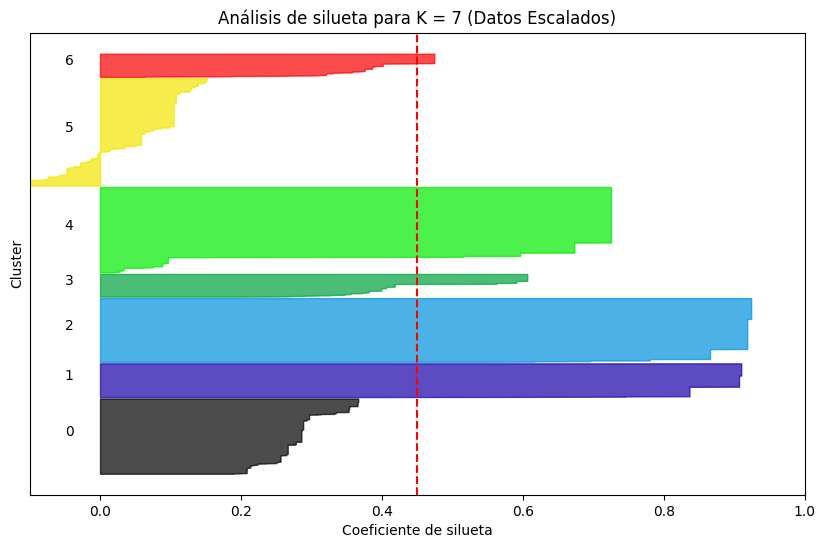

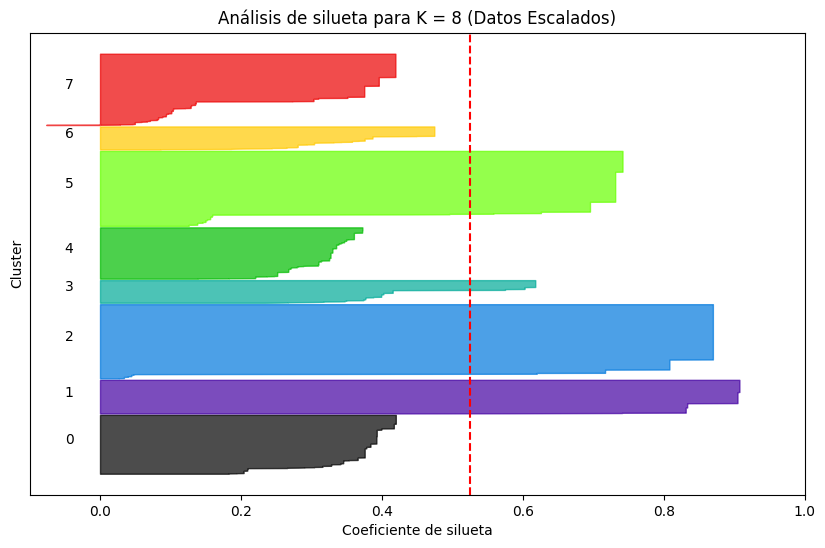

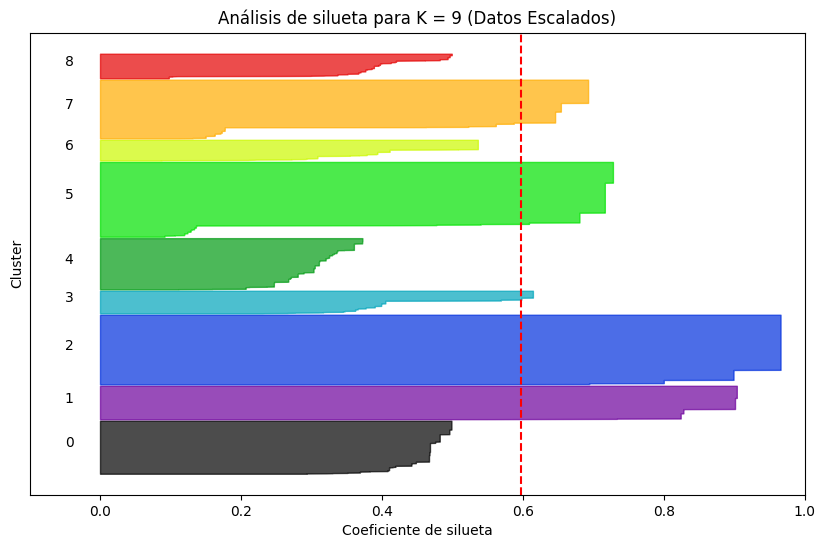

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler # <--- Importante
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# 1. Escalar los datos antes de procesar
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_dummies)

# Definimos los valores de K que queremos probar
range_n_clusters = [3, 4, 5, 6, 7, 8, 9]

for n_clusters in range_n_clusters:
    # Crear la figura
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(10, 6)

    # 2. Entrenar usando los datos ESCALADOS
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    cluster_labels = km.fit_predict(df_scaled)
    
    # 3. Calcular métricas usando los datos ESCALADOS
    sil_avg = silhouette_score(df_scaled, cluster_labels)
    sample_sil_values = silhouette_samples(df_scaled, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Agrupar y ordenar valores de silueta por cluster
        ith_cluster_sil_values = sample_sil_values[cluster_labels == i]
        ith_cluster_sil_values.sort()

        size_cluster_i = ith_cluster_sil_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Etiqueta con el número del cluster
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10 

    # Configuración estética del gráfico
    ax1.axvline(x=sil_avg, color="red", linestyle="--")
    ax1.set_title(f"Análisis de silueta para K = {n_clusters} (Datos Escalados)")
    ax1.set_xlabel("Coeficiente de silueta")
    ax1.set_ylabel("Cluster")
    ax1.set_yticks([]) 
    ax1.set_xlim([-0.1, 1]) # Rango estándar para siluetas

plt.show()

#### Genera el K Means 

Distribución de fármacos por cluster:
cluster
0    963
1    898
2    999
3    247
Name: count, dtype: int64


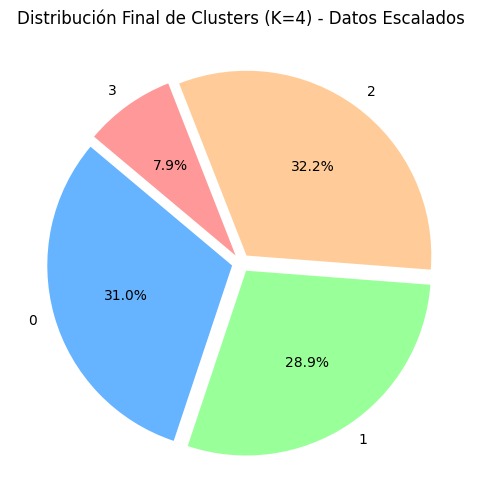

In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Preparación de los datos (Asegúrate de que df_scaled venga del mismo scaler)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_dummies)

# 2. Configuramos y entrenamos el modelo final con K=4
k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init='auto')

# ¡IMPORTANTE!: Entrenamos con df_scaled, NO con df_dummies
cluster_labels = kmeans.fit_predict(df_scaled)

# 3. Añadimos los resultados al DataFrame original (o filtrado) para análisis humano
df_filtered['cluster'] = cluster_labels

# 4. Comprobación de resultados: Conteo por cluster
print("Distribución de fármacos por cluster:")
print(df_filtered['cluster'].value_counts().sort_index())

# 5. Generación del Pie Plot (Gráfico de tarta)
plt.figure(figsize=(8, 6))
# Usamos value_counts para obtener el tamaño de cada "quesito"
df_filtered['cluster'].value_counts().sort_index().plot.pie(
    autopct='%1.1f%%', 
    startangle=140, 
    colors=['#66b3ff','#99ff99','#ffcc99','#ff9999'],
    explode=(0.05, 0.05, 0.05, 0.05) # Separa los trozos para mayor claridad
)

plt.title(f'Distribución Final de Clusters (K={k_final}) - Datos Escalados')
plt.ylabel('') 
plt.show()

Comprueba los resultados y muestra en un pie plot la distribución de los distintos clusters.

In [8]:

# calcular la moda por cada cluster
get_mode = lambda x: pd.Series.mode(x).iloc[0] if not pd.Series.mode(x).empty else np.nan

# Análisis descriptivo agrupado
# Nota: Usamos df_filtered porque ya contiene la columna 'cluster' asignada anteriormente
analisis = df_filtered.groupby('cluster').agg({
    'rating': get_mode,
    'effectiveness': get_mode, 
    'sideEffects': get_mode,
})

# Renombramos las columnas para que el reporte sea claro
# Como usas la moda, "Frecuente" o "Típico" es más preciso que "Promedio"
analisis.columns = ['Rating más Frecuente', 'Efectividad Típica', 'Efecto Secundario Típico']

# Mostramos el resultado
print("Resumen de características por Cluster (Moda):")
display(analisis) # Usamos display para una tabla más bonita en Jupyter/Colab

Resumen de características por Cluster (Moda):


,Rating más Frecuente,Efectividad Típica,Efecto Secundario Típico
cluster,,,
0,8,Highly Effective,Moderate Side Effects
1,10,Highly Effective,No Side Effects
2,8,Highly Effective,Mild Side Effects
3,1,Ineffective,Severe Side Effects
